# Energy regression on the hadron runs

**Goal:** given a single detector event, predict the beam energy of the run it
came from. We use only the **hadron 4xx runs** (`particle == "h"`, runs 445-459, which span eight beam energies:

| run | 445 | 446 | 448 | 450 | 451 | 452 | 458 | 459 |
|-----|-----|-----|-----|-----|-----|-----|-----|-----|
| E [GeV] | 150 | 200 | 300 | 100 | 80 | 60 | 250 | 350 |

The model and data pipeline are adapted from the e/h classifier
(`Rasmus/Classifier/Classifier_60GeV.ipynb`): same ROOT loading, same
per-channel pedestal normalization, same small CNN backbone. 


In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import copy
import uproot
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Subset


def find_project_root(marker="Data", start=None):
    """Walk up from `start` (default: cwd) until we find a directory containing `marker`."""
    p = (start or Path.cwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).is_dir():
            return candidate
    raise FileNotFoundError(f"Could not find '{marker}' starting from {p}")

PROJECT_ROOT = find_project_root("Data")
DATA_DIR     = PROJECT_ROOT / "Data"
LABELS_CSV   = DATA_DIR / "runs.csv"
print("project root:", PROJECT_ROOT)

project root: /Users/prometheus/Documents/Python/ML_FoCal_FinalProject


In [2]:
# data loading
labels_df = pd.read_csv(LABELS_CSV)
# Keep only the hadron 4xx runs (energy scan at bias 0).
runs_df = labels_df.query("particle == 'h' and 400 <= run < 500").sort_values("energy_GeV").copy()
print("runs to load:")
print(runs_df.to_string(index=False))

def find_root_file(run, data_dir=DATA_DIR):
    """Match either RunXXXX.root or RunXXX_EventMatch.root naming."""
    candidates = list(data_dir.glob(f"Run{run}*.root")) + list(data_dir.glob(f"Run{run:04d}*.root"))
    if not candidates:
        raise FileNotFoundError(f"No ROOT file for run {run}")
    return candidates[0]

# Pre-count entries so we can preallocate (raw kept as uint16 to halve memory:
# ADC values are in 0..1023, which fits comfortably).
counts = {}
for _, row in runs_df.iterrows():
    t = uproot.open(find_root_file(int(row["run"])))["data_tree"]
    counts[int(row["run"])] = t.num_entries
N_total = sum(counts.values())
print(f"\ntotal events to load: {N_total}")

val0    = np.empty((N_total, 2, 38, 64), dtype=np.uint16)
run_id  = np.empty(N_total, dtype=np.int32)
energy  = np.empty(N_total, dtype=np.float32)   # beam energy in GeV (regression target)

pos = 0
for _, row in runs_df.iterrows():
    run, E = int(row["run"]), float(row["energy_GeV"])
    t = uproot.open(find_root_file(run))["data_tree"]
    n = t.num_entries
    a0 = t["val0_list_0"].array(library="np").reshape(-1, 38, 64)
    a1 = t["val0_list_1"].array(library="np").reshape(-1, 38, 64)
    val0[pos:pos + n]   = np.stack([a0, a1], axis=1).astype(np.uint16)
    run_id[pos:pos + n] = run
    energy[pos:pos + n] = E
    pos += n
    print(f"  Run{run:04d}: {n:6d} events  ({E:.0f} GeV)")

assert pos == N_total
print(f"\nloaded val0: shape={val0.shape}  dtype={val0.dtype}  ({val0.nbytes / 1e9:.2f} GB)")

runs to load:
 run  energy_GeV particle  bias_V
 452          60        h       0
 451          80        h       0
 450         100        h       0
 445         150        h       0
 446         200        h       0
 458         250        h       0
 448         300        h       0
 459         350        h       0

total events to load: 274465
  Run0452:  37338 events  (60 GeV)
  Run0451:  34088 events  (80 GeV)
  Run0450:  32905 events  (100 GeV)
  Run0445:  32969 events  (150 GeV)
  Run0446:  33434 events  (200 GeV)
  Run0458:  35122 events  (250 GeV)
  Run0448:  34683 events  (300 GeV)
  Run0459:  33926 events  (350 GeV)

loaded val0: shape=(274465, 2, 38, 64)  dtype=uint16  (2.67 GB)


### Data shape

Loaded as `val0` with shape `(N, 2, 38, 64)`:

| Dim | Size | Meaning |
|-----|------|---------|
| 0   | N    | event index (one event = one trigger) |
| 1   | 2    | detector halves: `h0`, `h1` |
| 2   | 38   | chips per half |
| 3   | 64   | readout channels per chip |

Parallel label arrays of length N: `run_id` and `energy` (the GeV value we
regress on).

val0 shape: (274465, 2, 38, 64)  dtype: uint16
value range: 0 .. 1023
mean: 114.7  nonzero fraction: 0.968

events per energy:
            n_events  run
energy_GeV               
60.0           37338  452
80.0           34088  451
100.0          32905  450
150.0          32969  445
200.0          33434  446
250.0          35122  458
300.0          34683  448
350.0          33926  459


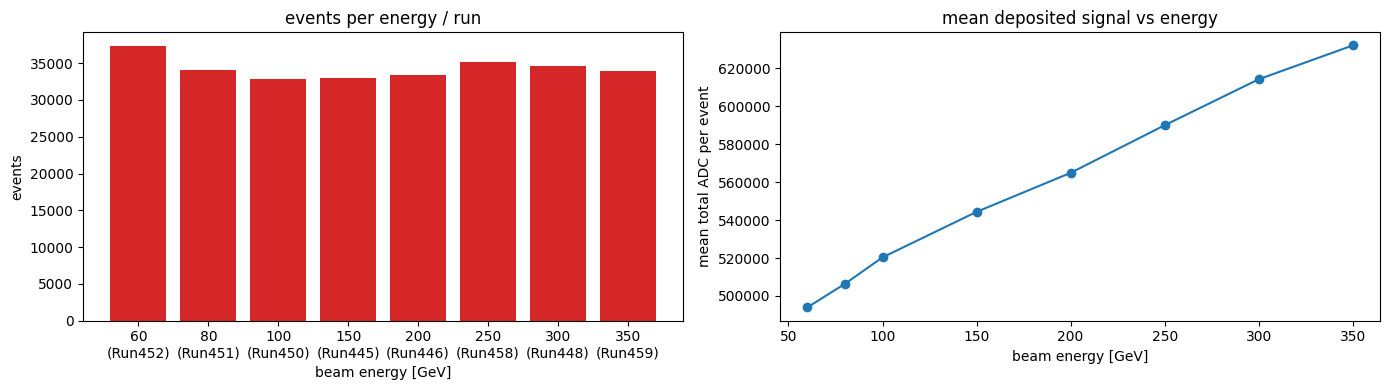

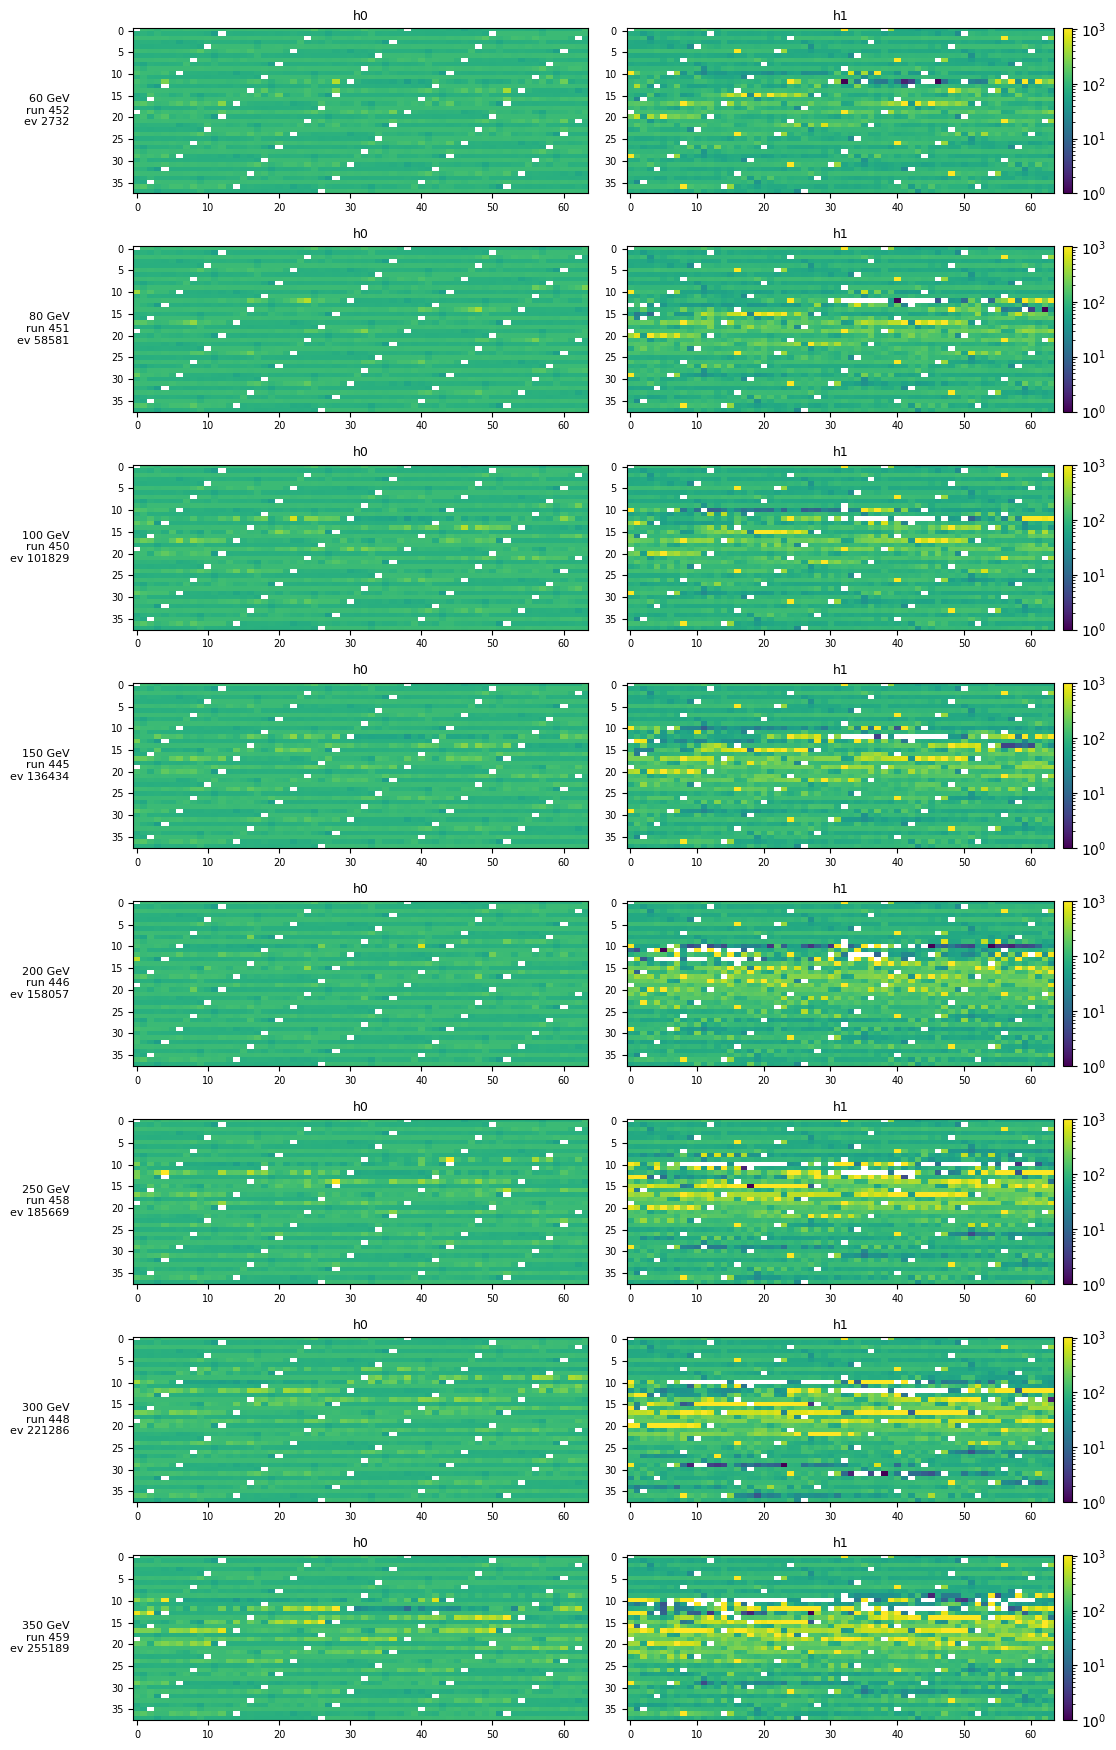

In [3]:
# Visualisation of the data (counts and example events)
print(f"val0 shape: {val0.shape}  dtype: {val0.dtype}")
print(f"value range: {val0.min()} .. {val0.max()}")
print(f"mean: {val0.mean():.1f}  nonzero fraction: {(val0 > 0).mean():.3f}")

summary = (pd.DataFrame({"run": run_id, "energy_GeV": energy})
           .groupby("energy_GeV").agg(n_events=("run", "size"), run=("run", "first")))
print("\nevents per energy:")
print(summary)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar([f"{int(E)}\n(Run{int(r)})" for E, r in zip(summary.index, summary.run)],
          summary.n_events, color="#d62728")
ax[0].set_ylabel("events"); ax[0].set_xlabel("beam energy [GeV]")
ax[0].set_title("events per energy / run")

# Mean total ADC per event vs energy -- the simplest physics sanity check:
# a calorimeter should deposit more signal at higher energy.
event_sum = val0.sum(axis=(1, 2, 3), dtype=np.int64)
mean_sum  = [event_sum[energy == E].mean() for E in summary.index]
ax[1].plot(summary.index, mean_sum, "o-", color="#1f77b4")
ax[1].set_xlabel("beam energy [GeV]"); ax[1].set_ylabel("mean total ADC per event")
ax[1].set_title("mean deposited signal vs energy")
plt.tight_layout(); plt.show()

# One example event per energy -- both halves
from matplotlib.colors import LogNorm
energies_sorted = np.array(sorted(np.unique(energy)))
fig, ax = plt.subplots(len(energies_sorted), 2, figsize=(11, 2.2 * len(energies_sorted)), squeeze=False)
rng = np.random.RandomState(0)
for gi, E in enumerate(energies_sorted):
    idx = rng.choice(np.where(energy == E)[0])
    ev  = val0[idx]
    vmax = max(int(np.percentile(ev, 99.5)), 2)
    for h in range(2):
        im = ax[gi, h].imshow(ev[h], aspect="auto", cmap="viridis",
                              norm=LogNorm(vmin=1, vmax=vmax))
        ax[gi, h].set_title(f"h{h}", fontsize=9)
        ax[gi, h].tick_params(labelsize=7)
    plt.colorbar(im, ax=ax[gi, 1], fraction=0.04, pad=0.02)
    ax[gi, 0].set_ylabel(f"{int(E)} GeV\nrun {run_id[idx]}\nev {idx}",
                         rotation=0, ha="right", va="center", labelpad=30, fontsize=8)
plt.tight_layout(); plt.subplots_adjust(left=0.10); plt.show()

### Per-run pedestal normalization

For each **run**, take the quietest 50% of events by total ADC — mostly
noise/pedestal events where the hadron deposited little — and use them to
compute a per-channel mean and std. Then z-score every event of that run.


In [4]:
""" Pedestal normalization, computed separately per run.
For each run, the quietest 50% of events (lowest total ADC) define the
per-channel pedestal mean/std; all events of that run are z-scored by them.
"""

event_sum = val0.sum(axis=(1, 2, 3), dtype=np.int64)

pedestals = {}  # run -> (mean (2,38,64), std (2,38,64))
for r in np.unique(run_id):
    in_run = run_id == r
    cutoff = np.percentile(event_sum[in_run], 50)
    quiet  = in_run & (event_sum < cutoff)
    mean   = val0[quiet].mean(axis=0).astype(np.float32)
    std    = val0[quiet].std(axis=0).astype(np.float32)
    pedestals[int(r)] = (mean, std)
    print(f"Run{r:04d}: {quiet.sum():6d} quiet events used  "
          f"mean ADC {mean.min():.1f}..{mean.max():.1f}  avg std {std.mean():.2f}")

# Apply normalization in place per-run slice (avoids a second full-size copy)
val0_norm = np.empty(val0.shape, dtype=np.float32)
for r, (mean, std) in pedestals.items():
    m = run_id == r
    val0_norm[m] = (val0[m].astype(np.float32) - mean) / (std + 1e-3)

print(f"\nnormalized: shape={val0_norm.shape}  dtype={val0_norm.dtype}  "
      f"memory={val0_norm.nbytes / 1e9:.2f} GB")
print(f"mean: {val0_norm.mean():+.3f}  (should be ~0 since most events are quiet)")
print(f"std : {val0_norm.std():.3f}  (close to 1 if normalization is sane)")

Run0445:  16482 quiet events used  mean ADC 0.0..1023.0  avg std 29.56
Run0446:  16717 quiet events used  mean ADC 0.0..1023.0  avg std 34.42
Run0448:  17341 quiet events used  mean ADC 0.0..1023.0  avg std 41.84
Run0450:  16452 quiet events used  mean ADC 0.0..1023.0  avg std 20.33
Run0451:  17042 quiet events used  mean ADC 0.0..1023.0  avg std 17.49
Run0452:  18669 quiet events used  mean ADC 0.0..1023.0  avg std 14.22
Run0458:  17559 quiet events used  mean ADC 0.0..1023.0  avg std 38.63
Run0459:  16963 quiet events used  mean ADC 0.0..1023.0  avg std 45.14

normalized: shape=(274465, 2, 38, 64)  dtype=float32  memory=5.34 GB
mean: +0.046  (should be ~0 since most events are quiet)
std : 1.064  (close to 1 if normalization is sane)


### Building the regression dataset

**Input:** `(N, 2, 38, 64)` — the two pedestal-normalized detector halves.

**Target:** beam energy in GeV. Neural nets train more stably on a standardized
target, so we fit on `y_norm = (E - mean) / std` (statistics computed on the
**train split only**, to avoid leaking test information) and invert back to GeV
for every reported metric.

**Splits**, all stratified on energy so each of the 8 energies appears in the
same proportion in every split:
- **train (70%)** — fit weights
- **val (15%)** — early stopping / model monitoring
- **test (15%)** — final per-event evaluation, looked at exactly once

A held-out *whole energy* is impossible here (one energy = one run, so removing
it removes that label entirely from training). 

In [5]:
# 2-channel input: the two normalized halves. Target: beam energy (GeV).
x_tensor = val0_norm
y_gev    = energy.astype(np.float32)

print(f"x: {x_tensor.shape}  {x_tensor.nbytes / 1e9:.2f} GB")
print(f"y: {y_gev.shape}  energies: {sorted(np.unique(y_gev).astype(int).tolist())}")

# Stratify on energy so every split has all 8 energies in proportion
strat = energy.astype(int).astype(str)

idx_trainval, idx_test = train_test_split(
    np.arange(len(x_tensor)), test_size=0.15, stratify=strat, random_state=0)
idx_train, idx_val = train_test_split(
    idx_trainval, test_size=0.15 / 0.85, stratify=strat[idx_trainval], random_state=0)
print(f"\nsplit sizes:  train {len(idx_train)}  val {len(idx_val)}  test {len(idx_test)}")

# Standardize the target using TRAIN statistics only
Y_MEAN = float(y_gev[idx_train].mean())
Y_STD  = float(y_gev[idx_train].std())
print(f"target standardization (train):  mean={Y_MEAN:.2f} GeV  std={Y_STD:.2f} GeV")
y_norm = (y_gev - Y_MEAN) / Y_STD

ds = TensorDataset(torch.from_numpy(x_tensor), torch.from_numpy(y_norm))
train_ds = Subset(ds, idx_train)
val_ds   = Subset(ds, idx_val)
test_ds  = Subset(ds, idx_test)   # set aside, do not peek

BATCH = 256
train_loader = DataLoader(train_ds, batch_size=BATCH,     shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH * 2, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH * 2, shuffle=False, num_workers=0)

xb, yb = next(iter(train_loader))
print(f"\nbatch x: {tuple(xb.shape)} {xb.dtype}   y: {tuple(yb.shape)} {yb.dtype}")

x: (274465, 2, 38, 64)  5.34 GB
y: (274465,)  energies: [60, 80, 100, 150, 200, 250, 300, 350]

split sizes:  train 192125  val 41170  test 41170
target standardization (train):  mean=185.63 GeV  std=100.56 GeV

batch x: (256, 2, 38, 64) torch.float32   y: (256,) torch.float32


### CNN regressor architecture

Same convolutional backbone as the classifier (~26K params), but the head emits
a **single scalar** instead of class logits.

| Layer | Output shape | Notes |
|-------|-------------|-------|
| Input | `(B, 2, 38, 64)` | 2 normalized halves |
| Conv2d(2→16, 3×3) + BN + ReLU | `(B, 16, 38, 64)` | |
| Conv2d(16→32, 3×3, stride 2) + BN + ReLU | `(B, 32, 19, 32)` | downsample |
| Conv2d(32→64, 3×3, stride 2) + BN + ReLU | `(B, 64, 10, 16)` | downsample |
| AdaptiveAvgPool2d(1) + Flatten | `(B, 64)` | translation invariance |
| Dropout(0.3) + Linear(64→32) + ReLU | `(B, 32)` | |
| Dropout(0.3) + Linear(32→1) | `(B, 1)` | regressed standardized energy |

Global average pooling keeps the same translation invariance argument as the
classifier: a shower in chip 5 vs chip 25 pools to roughly the same feature.

In [6]:
"""
CNN regressor for beam energy. Same backbone as the e/h classifier; the head
outputs one scalar (the standardized energy), squeezed to shape (B,).
"""

class CNNRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(2, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),  # 38x64 -> 19x32
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),  # 19x32 -> 10x16
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # (B, 64, 1, 1)
            nn.Flatten(),             # (B, 64)
            nn.Dropout(0.3),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.head(self.features(x)).squeeze(1)  # (B,)


device = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available()
          else "cpu")
model = CNNRegressor().to(device)

with torch.no_grad():
    dummy = torch.zeros(2, 2, 38, 64, device=device)
    out = model(dummy)
    assert out.shape == (2,), out.shape
    print(f"output shape ok: {tuple(out.shape)}")

print(f"\ndevice: {device}   params: {sum(p.numel() for p in model.parameters()):,}")
print(model)

output shape ok: (2,)

device: mps   params: 25,777
CNNRegressor(
  (features): Sequential(
    (0): Conv2d(2, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
  )
  (head): Sequential(
    (0): AdaptiveAvgPool2d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


### Training pipeline

Same recipe as the classifier, retargeted for regression:

1. **Optimizer:** `AdamW(weight_decay=1e-4)`.
2. **Loss:** `HuberLoss` (smooth L1) on the standardized target — less sensitive
   than MSE to the occasional pathological event (e.g. a shower that mostly
   missed the detector).
3. **LR scheduler:** `ReduceLROnPlateau` halves the LR after `LR_PATIENCE`
   epochs without val improvement.
4. **Early stopping:** stop after `PATIENCE` epochs without improvement and
   restore best-val-loss weights.



In [ ]:
"""
Train the CNN regressor with early stopping + LR scheduling.
- AdamW(weight_decay=1e-4) + HuberLoss on the standardized target
- ReduceLROnPlateau; early stop restores best-val-loss weights
- Best weights cached to Rasmus/regressor_hadron.pt; test set untouched
"""

MAX_EPOCHS   = 100
PATIENCE     = 12
LR_PATIENCE  = 4
MIN_DELTA    = 1e-4
LR           = 1e-3
WEIGHT_DECAY = 1e-4
RETRAIN      = False
REGRESSOR_WEIGHTS = PROJECT_ROOT / "Rasmus" / "Regression" / "regressor_hadron.pt"

history = {"train_loss": [], "val_loss": [], "val_mae_gev": [], "lr": []}

def eval_loss_mae(loader, loss_fn):
    """Return (mean Huber loss, MAE in GeV) over a loader."""
    model.eval()
    tot_loss, abs_err, n = 0.0, 0.0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            tot_loss += loss_fn(pred, yb).item() * xb.size(0)
            abs_err  += (torch.abs(pred - yb) * Y_STD).sum().item()  # back to GeV
            n += xb.size(0)
    return tot_loss / n, abs_err / n

if REGRESSOR_WEIGHTS.exists() and not RETRAIN:
    model.load_state_dict(torch.load(REGRESSOR_WEIGHTS, map_location=device))
    print(f"loaded cached weights from {REGRESSOR_WEIGHTS.name} (set RETRAIN=True to override)")
else:
    opt       = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", factor=0.5, patience=LR_PATIENCE, min_lr=1e-6)
    loss_fn = nn.HuberLoss()

    best_val_loss, best_epoch = float("inf"), -1
    best_state = copy.deepcopy(model.state_dict())
    bad_epochs = 0

    for epoch in range(MAX_EPOCHS):
        model.train()
        tr_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = loss_fn(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
            tr_loss += loss.item() * xb.size(0)
        tr_loss /= len(train_ds)

        va_loss, va_mae = eval_loss_mae(val_loader, loss_fn)
        scheduler.step(va_loss)
        cur_lr = opt.param_groups[0]["lr"]

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["val_mae_gev"].append(va_mae)
        history["lr"].append(cur_lr)

        improved = va_loss < best_val_loss - MIN_DELTA
        if improved:
            best_val_loss, best_epoch = va_loss, epoch
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs, tag = 0, " *"
        else:
            bad_epochs += 1; tag = ""
        print(f"epoch {epoch+1:3d}/{MAX_EPOCHS}  train={tr_loss:.4f}  "
              f"val_loss={va_loss:.4f}  val_MAE={va_mae:5.1f} GeV  "
              f"lr={cur_lr:.1e}  bad={bad_epochs}{tag}")

        if bad_epochs >= PATIENCE:
            print(f"\nearly stop at epoch {epoch+1}: no improvement for {PATIENCE} epochs")
            break

    model.load_state_dict(best_state)
    torch.save(best_state, REGRESSOR_WEIGHTS)
    print(f"\nbest val_loss={best_val_loss:.4f}  "
          f"val_MAE={history['val_mae_gev'][best_epoch]:.1f} GeV at epoch {best_epoch+1}")
    print(f"saved {REGRESSOR_WEIGHTS}")

epoch   1/100  train=0.1241  val_loss=0.0567  val_MAE= 25.2 GeV  lr=1.0e-03  bad=0 *
epoch   2/100  train=0.0634  val_loss=0.0408  val_MAE= 21.3 GeV  lr=1.0e-03  bad=0 *
epoch   3/100  train=0.0552  val_loss=0.0788  val_MAE= 30.2 GeV  lr=1.0e-03  bad=1
epoch   4/100  train=0.0499  val_loss=0.0304  val_MAE= 19.2 GeV  lr=1.0e-03  bad=0 *
epoch   5/100  train=0.0454  val_loss=0.0420  val_MAE= 22.5 GeV  lr=1.0e-03  bad=1
epoch   6/100  train=0.0427  val_loss=0.0452  val_MAE= 22.5 GeV  lr=1.0e-03  bad=2
epoch   7/100  train=0.0403  val_loss=0.0283  val_MAE= 17.1 GeV  lr=1.0e-03  bad=0 *
epoch   8/100  train=0.0382  val_loss=0.0220  val_MAE= 15.5 GeV  lr=1.0e-03  bad=0 *
epoch   9/100  train=0.0374  val_loss=0.0187  val_MAE= 14.4 GeV  lr=1.0e-03  bad=0 *
epoch  10/100  train=0.0359  val_loss=0.0354  val_MAE= 20.3 GeV  lr=1.0e-03  bad=1
epoch  11/100  train=0.0348  val_loss=0.0162  val_MAE= 13.3 GeV  lr=1.0e-03  bad=0 *
epoch  12/100  train=0.0339  val_loss=0.0158  val_MAE= 13.2 GeV  lr=1.0e-

### Validation evaluation

The standard regression diagnostics:

- **Predicted vs true** scatter (with the ideal `y = x` line). 
- **Residuals vs true energy** — reveals systematic bias (does the model
  under-predict high energies and over-predict low ones, the classic
  regression-to-the-mean pull?).
- **Per-energy summary:** mean prediction, bias, and resolution `σ/E`.
- Headline numbers: **MAE**, **RMSE** (both GeV), and **R²**.

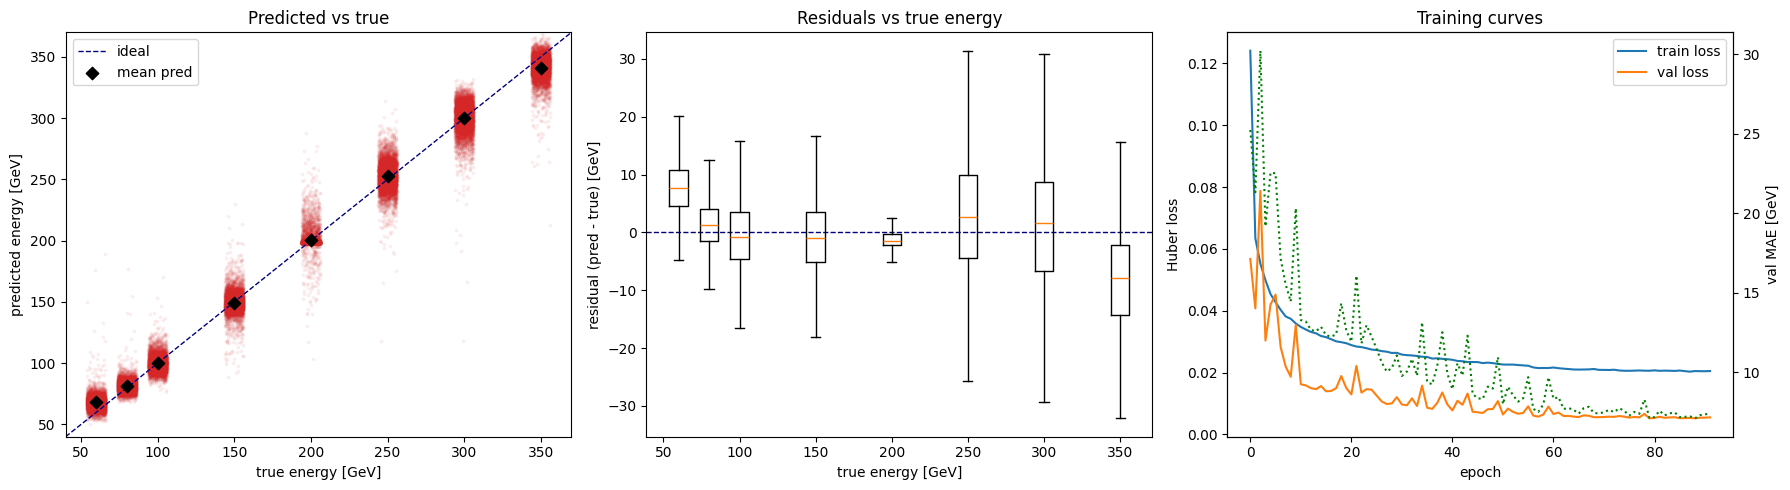

val MAE :    7.11 GeV
val RMSE:   10.28 GeV
val R^2 :  0.9895

per-energy summary:
   E[GeV]      n  mean pred     bias     std  sigma/E
       60   5601       67.9     +7.9     6.0    0.100
       80   5113       81.5     +1.5     5.0    0.063
      100   4936       99.9     -0.1     6.8    0.068
      150   4946      149.5     -0.5     9.2    0.061
      200   5015      200.4     +0.4     9.3    0.047
      250   5268      252.7     +2.7    12.1    0.048
      300   5202      300.1     +0.1    12.7    0.042
      350   5089      341.1     -8.9    10.2    0.029


In [8]:
"""Validation diagnostics for the regressor (everything reported in GeV)."""

def collect_predictions(loader, indices):
    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in loader:
            preds.append(model(xb.to(device)).cpu().numpy())
    pred_gev = np.concatenate(preds) * Y_STD + Y_MEAN
    true_gev = y_gev[indices]
    return true_gev, pred_gev

y_true, y_pred = collect_predictions(val_loader, np.asarray(val_ds.indices))

mae  = np.mean(np.abs(y_pred - y_true))
rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
r2   = r2_score(y_true, y_pred)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# --- predicted vs true ---
lo, hi = y_true.min() - 20, y_true.max() + 20
ax[0].plot([lo, hi], [lo, hi], "--", color="navy", lw=1, label="ideal")
ax[0].scatter(y_true + np.random.uniform(-6, 6, len(y_true)), y_pred,
              s=3, alpha=0.05, color="#d62728")
energies_sorted = np.array(sorted(np.unique(y_true)))
ax[0].scatter(energies_sorted, [y_pred[y_true == E].mean() for E in energies_sorted],
              color="black", marker="D", s=40, zorder=5, label="mean pred")
ax[0].set_xlabel("true energy [GeV]"); ax[0].set_ylabel("predicted energy [GeV]")
ax[0].set_title("Predicted vs true"); ax[0].legend(loc="upper left")
ax[0].set_xlim(lo, hi); ax[0].set_ylim(lo, hi)

# --- residuals vs true ---
resid = y_pred - y_true
ax[1].axhline(0, color="navy", ls="--", lw=1)
parts = [resid[y_true == E] for E in energies_sorted]
ax[1].boxplot(parts, positions=energies_sorted, widths=12, showfliers=False,
              manage_ticks=False)
ax[1].set_xlabel("true energy [GeV]"); ax[1].set_ylabel("residual (pred - true) [GeV]")
ax[1].set_title("Residuals vs true energy")

# --- training curves ---
if history["train_loss"]:
    ax2b = ax[2].twinx()
    ax[2].plot(history["train_loss"], label="train loss", color="#1f77b4")
    ax[2].plot(history["val_loss"],   label="val loss",   color="#ff7f0e")
    ax2b.plot(history["val_mae_gev"], label="val MAE", color="green", ls=":")
    ax[2].set_xlabel("epoch"); ax[2].set_ylabel("Huber loss")
    ax2b.set_ylabel("val MAE [GeV]")
    ax[2].set_title("Training curves"); ax[2].legend(loc="upper right")
else:
    ax[2].text(0.5, 0.5, "no training history\n(loaded from cache)",
               ha="center", va="center", transform=ax[2].transAxes, fontsize=11)
    ax[2].set_xticks([]); ax[2].set_yticks([]); ax[2].set_title("Training curves")

plt.tight_layout(); plt.show()

print(f"val MAE :  {mae:6.2f} GeV")
print(f"val RMSE:  {rmse:6.2f} GeV")
print(f"val R^2 :  {r2:6.4f}")
print("\nper-energy summary:")
print(f"  {'E[GeV]':>7} {'n':>6} {'mean pred':>10} {'bias':>8} {'std':>7} {'sigma/E':>8}")
for E in energies_sorted:
    m = y_true == E
    mp, sd = y_pred[m].mean(), y_pred[m].std()
    print(f"  {int(E):>7} {m.sum():>6} {mp:>10.1f} {mp - E:>+8.1f} {sd:>7.1f} {sd / E:>8.3f}")

### Final test-set evaluation

The held-out 15% test split, never seen during training or model selection. Run
this **once**, at the end. If you change the model based on what you see here,
it stops being a test set.

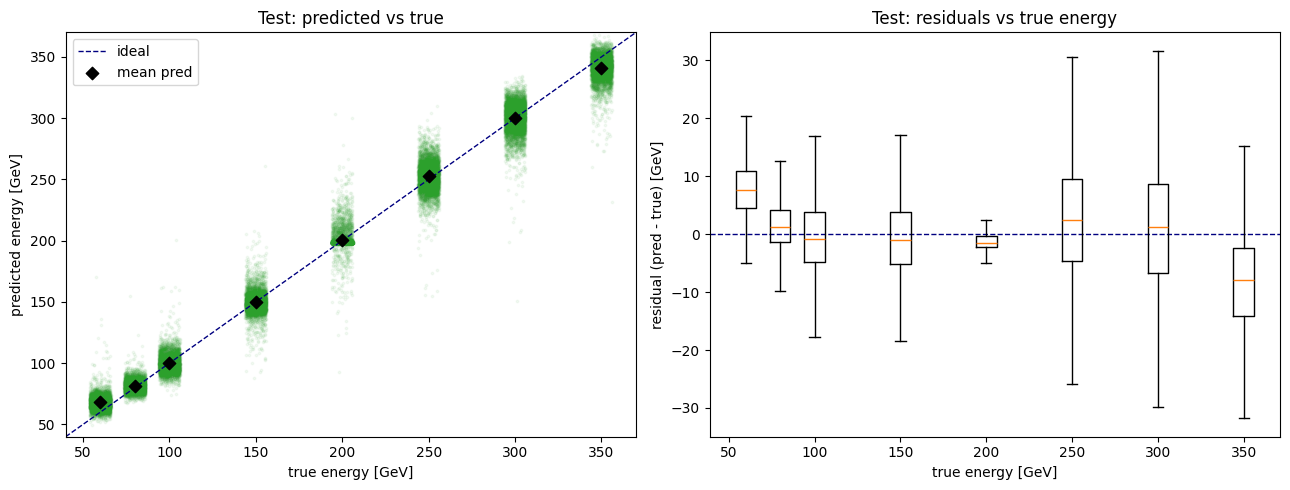

test MAE :    7.15 GeV
test RMSE:   10.24 GeV
test R^2 :  0.9896

per-energy summary:
   E[GeV]      n  mean pred     bias     std  sigma/E
       60   5601       67.9     +7.9     5.6    0.094
       80   5113       81.6     +1.6     4.7    0.059
      100   4936      100.0     +0.0     7.4    0.074
      150   4945      149.7     -0.3     9.2    0.061
      200   5015      200.4     +0.4     9.4    0.047
      250   5268      252.4     +2.4    12.1    0.048
      300   5203      300.2     +0.2    12.4    0.041
      350   5089      341.1     -8.9    10.2    0.029


In [9]:
"""FINAL test-set evaluation -- run once."""

y_true, y_pred = collect_predictions(test_loader, np.asarray(test_ds.indices))

mae  = np.mean(np.abs(y_pred - y_true))
rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
r2   = r2_score(y_true, y_pred)
energies_sorted = np.array(sorted(np.unique(y_true)))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

lo, hi = y_true.min() - 20, y_true.max() + 20
ax[0].plot([lo, hi], [lo, hi], "--", color="navy", lw=1, label="ideal")
ax[0].scatter(y_true + np.random.uniform(-6, 6, len(y_true)), y_pred,
              s=3, alpha=0.05, color="#2ca02c")
ax[0].scatter(energies_sorted, [y_pred[y_true == E].mean() for E in energies_sorted],
              color="black", marker="D", s=40, zorder=5, label="mean pred")
ax[0].set_xlabel("true energy [GeV]"); ax[0].set_ylabel("predicted energy [GeV]")
ax[0].set_title("Test: predicted vs true"); ax[0].legend(loc="upper left")
ax[0].set_xlim(lo, hi); ax[0].set_ylim(lo, hi)

ax[1].axhline(0, color="navy", ls="--", lw=1)
parts = [(y_pred - y_true)[y_true == E] for E in energies_sorted]
ax[1].boxplot(parts, positions=energies_sorted, widths=12, showfliers=False,
              manage_ticks=False)
ax[1].set_xlabel("true energy [GeV]"); ax[1].set_ylabel("residual (pred - true) [GeV]")
ax[1].set_title("Test: residuals vs true energy")
plt.tight_layout(); plt.show()

print(f"test MAE :  {mae:6.2f} GeV")
print(f"test RMSE:  {rmse:6.2f} GeV")
print(f"test R^2 :  {r2:6.4f}")
print("\nper-energy summary:")
print(f"  {'E[GeV]':>7} {'n':>6} {'mean pred':>10} {'bias':>8} {'std':>7} {'sigma/E':>8}")
for E in energies_sorted:
    m = y_true == E
    mp, sd = y_pred[m].mean(), y_pred[m].std()
    print(f"  {int(E):>7} {m.sum():>6} {mp:>10.1f} {mp - E:>+8.1f} {sd:>7.1f} {sd / E:>8.3f}")

### Leave-one-energy-out: did it learn physics or memorize runs?

This is the honest test promised at the top. We **remove one entire energy**
(its whole run) from training, train a fresh model on the other seven, then ask
it to predict the held-out energy.

- If the model learned a genuine, smooth energy response, it should **interpolate**
  — predict the held-out energy roughly correctly even though it never saw it.
- If it merely memorized run fingerprints, it has no fingerprint for the missing
  run and will fall back to predicting something like the mean of the energies
  it *did* see — i.e. it cannot extrapolate/interpolate at all.

This retrains from scratch, so it is **off by default**. Set `RUN_LOEO = True`
and pick `HOLDOUT_E` (an interior energy like 150 or 200 makes the cleanest
interpolation test). Results are not cached.

holding out 150 GeV (32969 events); training on 241496 events from [ 60  80 100 200 250 300 350]
  epoch   1  val_loss=0.0372  bad=0
  epoch   2  val_loss=0.0592  bad=1
  epoch   3  val_loss=0.0236  bad=0
  epoch   4  val_loss=0.0227  bad=0
  epoch   5  val_loss=0.0257  bad=1
  epoch   6  val_loss=0.0264  bad=2
  epoch   7  val_loss=0.0194  bad=0
  epoch   8  val_loss=0.0471  bad=1
  epoch   9  val_loss=0.0376  bad=2
  epoch  10  val_loss=0.0246  bad=3
  epoch  11  val_loss=0.0188  bad=0
  epoch  12  val_loss=0.0134  bad=0
  epoch  13  val_loss=0.0161  bad=1
  epoch  14  val_loss=0.0122  bad=0
  epoch  15  val_loss=0.0168  bad=1
  epoch  16  val_loss=0.0120  bad=0
  epoch  17  val_loss=0.0109  bad=0
  epoch  18  val_loss=0.0115  bad=1
  epoch  19  val_loss=0.0108  bad=0
  epoch  20  val_loss=0.0110  bad=1
  epoch  21  val_loss=0.0094  bad=0
  epoch  22  val_loss=0.0102  bad=1
  epoch  23  val_loss=0.0137  bad=2
  epoch  24  val_loss=0.0102  bad=3
  epoch  25  val_loss=0.0092  bad=0
  e

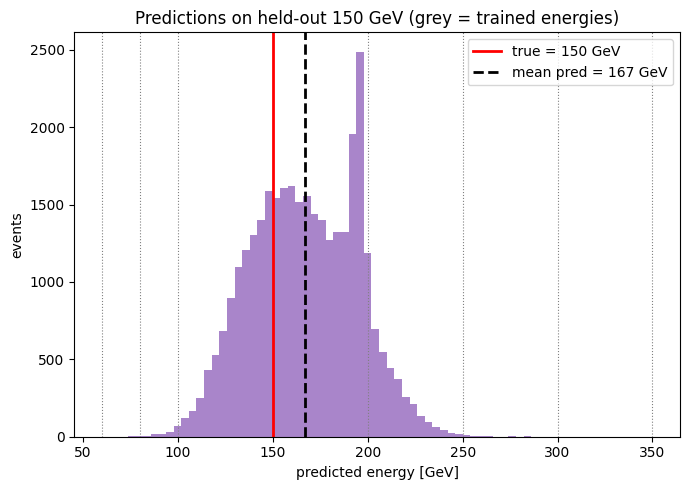


held-out true energy : 150 GeV
mean prediction      : 167.1 GeV
mean of seen energies: 190.5 GeV  (what a pure run-memorizer would default toward)
prediction MAE       : 26.8 GeV

Reading the result: a prediction centred near the true 150 GeV (and far from the seen-energy mean) is evidence of genuine energy interpolation; a prediction collapsed onto the seen-energy mean suggests run memorization.


In [11]:
"""Leave-one-energy-out interpolation test. Off by default (retrains a model)."""

RUN_LOEO  = True     # set True to run
HOLDOUT_E = 150       # GeV to hold out entirely from training

if not RUN_LOEO:
    print("RUN_LOEO is False -- skipping. Set it to True to run the interpolation test.")
else:
    holdout_mask = energy == HOLDOUT_E
    seen_mask    = ~holdout_mask
    seen_idx     = np.where(seen_mask)[0]
    print(f"holding out {int(HOLDOUT_E)} GeV ({holdout_mask.sum()} events); "
          f"training on {seen_mask.sum()} events from {np.unique(energy[seen_mask]).astype(int)}")

    # Standardize target on the SEEN energies only
    ym, ys = y_gev[seen_idx].mean(), y_gev[seen_idx].std()
    yn = (y_gev - ym) / ys

    s_strat = energy[seen_idx].astype(int).astype(str)
    s_train, s_val = train_test_split(seen_idx, test_size=0.15,
                                      stratify=s_strat, random_state=0)
    ds_l = TensorDataset(torch.from_numpy(x_tensor), torch.from_numpy(yn))
    ld_train = DataLoader(Subset(ds_l, s_train), batch_size=BATCH, shuffle=True)
    ld_val   = DataLoader(Subset(ds_l, s_val),   batch_size=BATCH * 2)

    loeo_model = CNNRegressor().to(device)
    opt = torch.optim.AdamW(loeo_model.parameters(), lr=1e-3, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=4, min_lr=1e-6)
    loss_fn = nn.HuberLoss()
    best, best_state, bad = float("inf"), None, 0
    for epoch in range(100):
        loeo_model.train()
        for xb, yb in ld_train:
            xb, yb = xb.to(device), yb.to(device)
            loss = loss_fn(loeo_model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
        loeo_model.eval(); vl, n = 0.0, 0
        with torch.no_grad():
            for xb, yb in ld_val:
                xb, yb = xb.to(device), yb.to(device)
                vl += loss_fn(loeo_model(xb), yb).item() * xb.size(0); n += xb.size(0)
        vl /= n; sched.step(vl)
        if vl < best - 1e-4:
            best, best_state, bad = vl, copy.deepcopy(loeo_model.state_dict()), 0
        else:
            bad += 1
        print(f"  epoch {epoch+1:3d}  val_loss={vl:.4f}  bad={bad}")
        if bad >= 12:
            break
    loeo_model.load_state_dict(best_state)

    # Predict the held-out energy
    loeo_model.eval(); preds = []
    with torch.no_grad():
        for i in range(0, holdout_mask.sum(), 512):
            chunk = x_tensor[np.where(holdout_mask)[0][i:i + 512]]
            preds.append(loeo_model(torch.from_numpy(chunk).to(device)).cpu().numpy())
    pred_holdout = np.concatenate(preds) * ys + ym
    seen_energies = np.array(sorted(np.unique(energy[seen_mask])))

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.hist(pred_holdout, bins=60, color="#9467bd", alpha=0.8)
    ax.axvline(HOLDOUT_E, color="red", lw=2, label=f"true = {int(HOLDOUT_E)} GeV")
    ax.axvline(pred_holdout.mean(), color="black", ls="--", lw=2,
               label=f"mean pred = {pred_holdout.mean():.0f} GeV")
    for E in seen_energies:
        ax.axvline(E, color="grey", ls=":", lw=0.8)
    ax.set_xlabel("predicted energy [GeV]"); ax.set_ylabel("events")
    ax.set_title(f"Predictions on held-out {int(HOLDOUT_E)} GeV (grey = trained energies)")
    ax.legend(); plt.tight_layout(); plt.show()

    seen_mean = energy[seen_mask].mean()
    print(f"\nheld-out true energy : {HOLDOUT_E:.0f} GeV")
    print(f"mean prediction      : {pred_holdout.mean():.1f} GeV")
    print(f"mean of seen energies: {seen_mean:.1f} GeV  "
          f"(what a pure run-memorizer would default toward)")
    print(f"prediction MAE       : {np.mean(np.abs(pred_holdout - HOLDOUT_E)):.1f} GeV")
    print("\nReading the result: a prediction centred near the true 150 GeV (and far "
          "from the seen-energy mean) is evidence of genuine energy interpolation; a "
          "prediction collapsed onto the seen-energy mean suggests run memorization.")